In [ ]:
import matplotlib.pyplot as plt
import torch
from matplotlib.axes import Axes

from flow_matching.base.probability import Density
from flow_matching.distributions import Gaussian, GaussianMixture
from flow_matching.flows import ConditionalVectorFieldODE
from flow_matching.paths import GaussianConditionalProbabilityPath, LinearAlpha, SquareRootBeta
from flow_matching.plot import every_nth_index, imshow_density
from flow_matching.simulator import EulerSimulator


In [ ]:
device = torch.device(  # noqa: F841
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

/Users/bkaplowitz/Developer/work/flow project/.venv/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


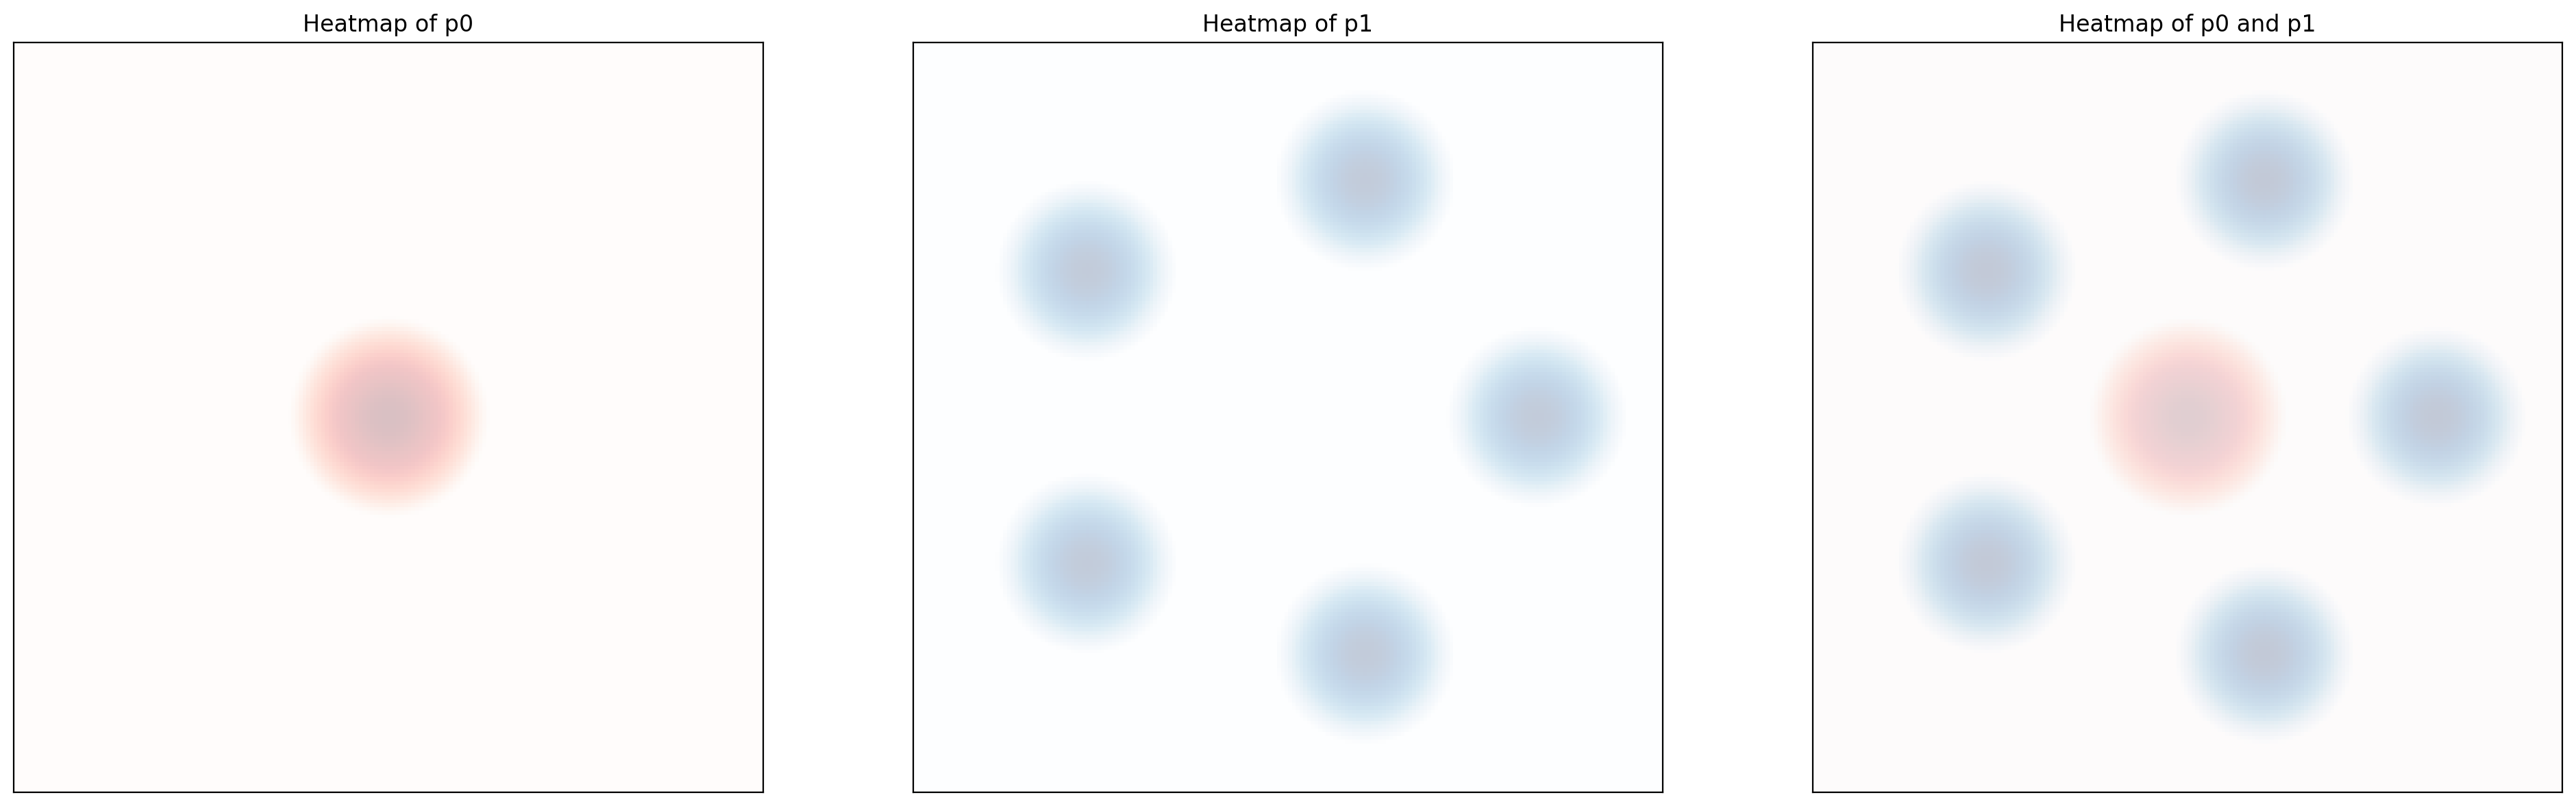

In [ ]:
PARAMS = {
    "scale": 15.0,
    "target_scale": 10.0,
    "target_std": 1.0,
}
# initial distribution
p0 = Gaussian.isotropic(dim=2, std=1.0).to(device)
# target
p1 = GaussianMixture.symmetric_2D(
    nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]
).to(device)

fig_gs, axes_gs = plt.subplots(1, 3, figsize=(24, 8))
bins = 200

scale = PARAMS["scale"]
x_bounds_gs = [-scale, scale]
y_bounds_gs = [-scale, scale]

axes_gs[0].set_title("Heatmap of p0")
axes_gs[0].set_xticks([])
axes_gs[0].set_yticks([])
imshow_density(
    density=p0,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    ax=axes_gs[0],
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Reds"),
)

axes_gs[1].set_title("Heatmap of p1")
axes_gs[1].set_xticks([])
axes_gs[1].set_yticks([])
imshow_density(
    density=p1,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    ax=axes_gs[1],
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Blues"),
)

axes_gs[2].set_title("Heatmap of p0 and p1")
axes_gs[2].set_xticks([])
axes_gs[2].set_yticks([])
imshow_density(
    density=p0,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Reds"),
)
imshow_density(
    density=p1,
    x_bounds=x_bounds_gs,
    y_bounds=y_bounds_gs,
    bins=bins,
    vmin=-10,
    alpha=0.25,
    cmap=plt.get_cmap("Blues"),
)
plt.show()

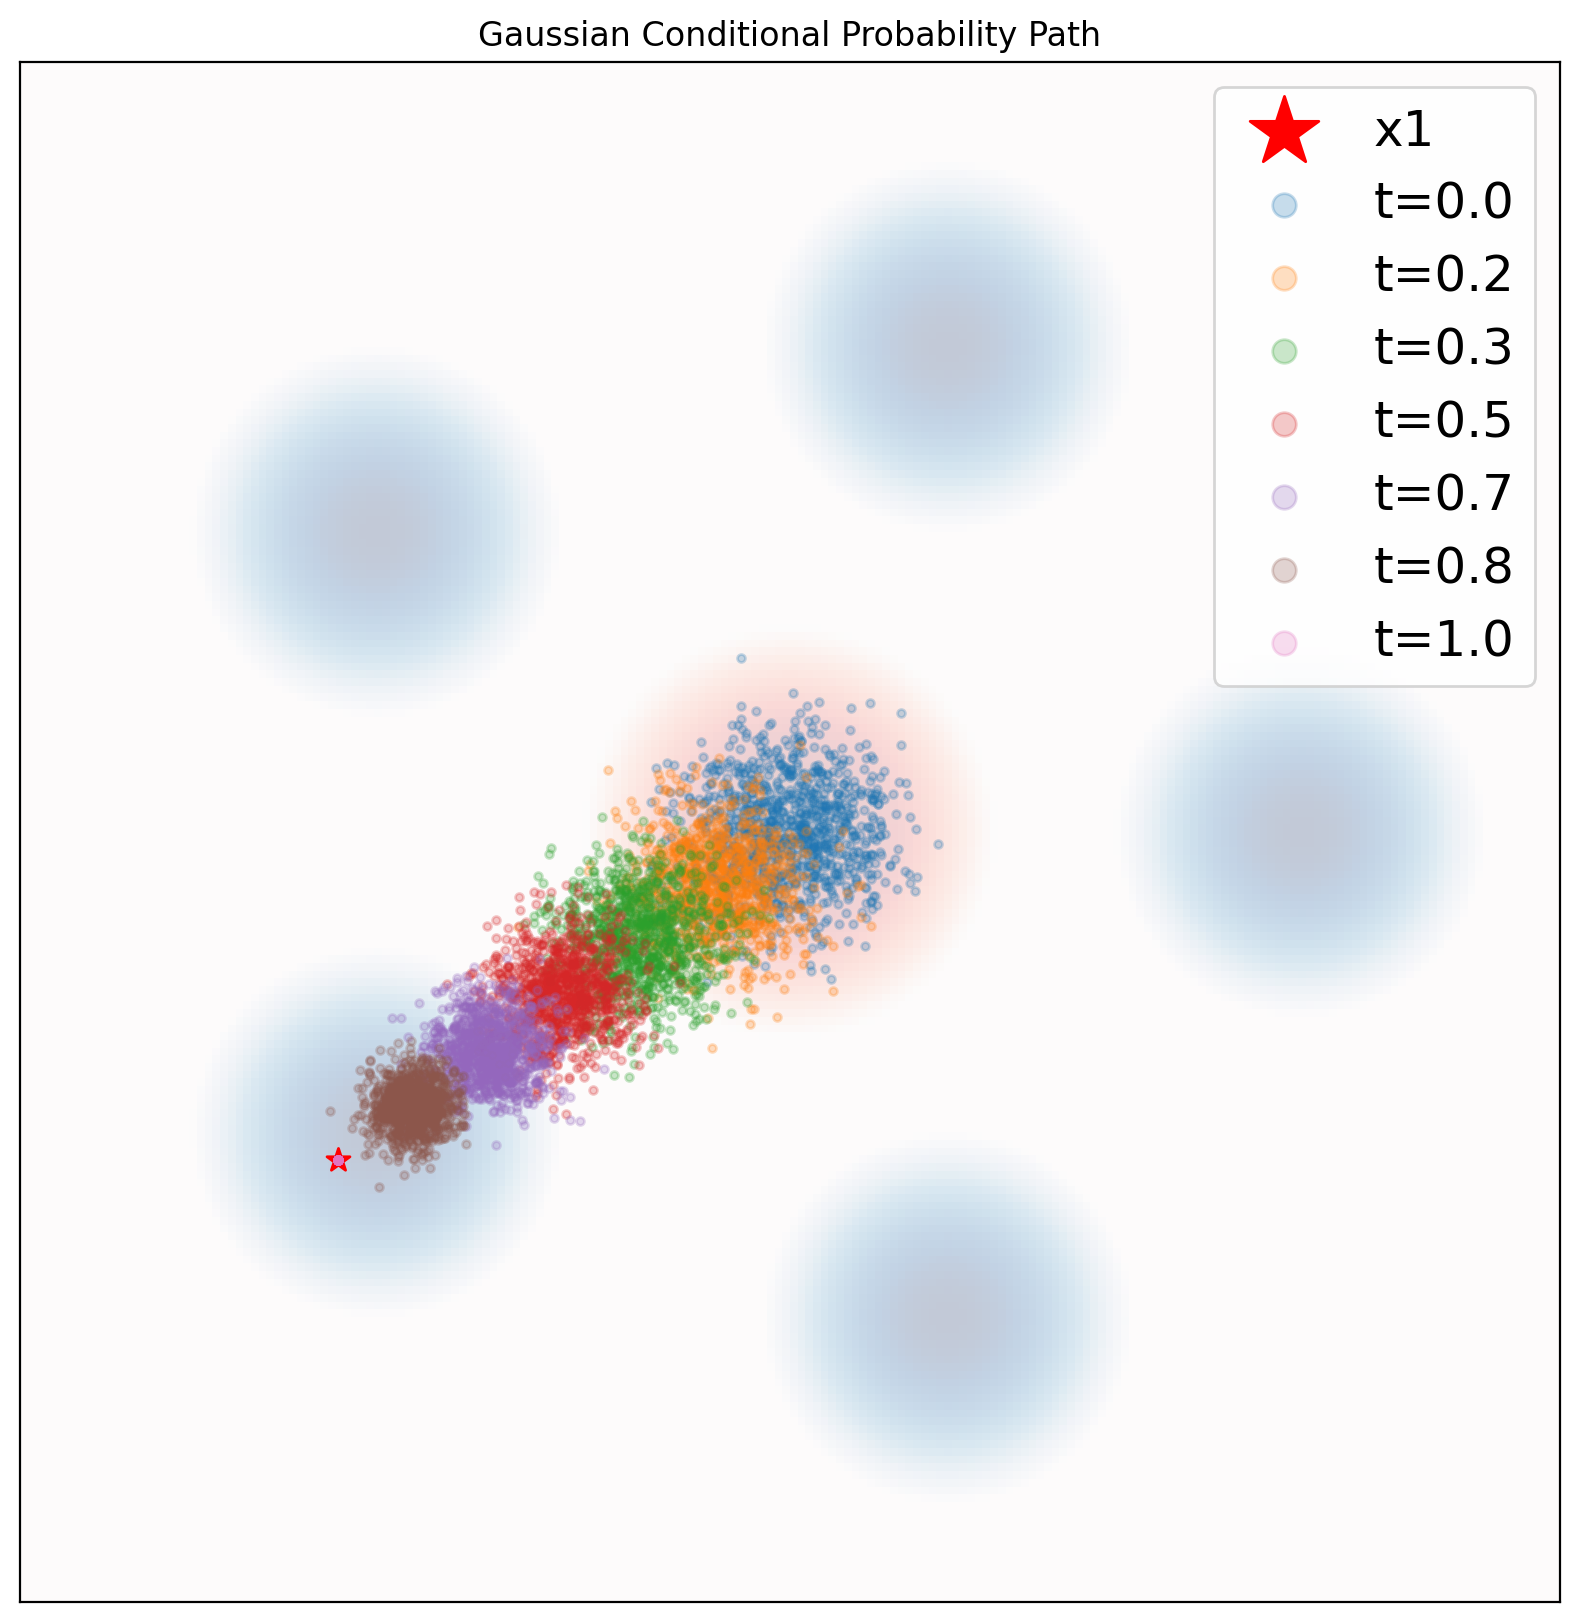

In [ ]:
def plot_conditional_probability_path() -> None:
    # Construct conditional probability path
    PARAMS = {"scale": 15.0, "target_scale": 10.0, "target_std": 1.0}
    bins = 200
    # Construct conditional probability path
    path = GaussianConditionalProbabilityPath(
        p1=GaussianMixture.symmetric_2D(  # target distribution
            nmodes=5, std=PARAMS["target_std"], scale=PARAMS["target_scale"]
        ).to(device),
        alpha=LinearAlpha(),
        beta=SquareRootBeta(),
    ).to(device)

    scale = PARAMS["scale"]
    x_bounds = [-scale, scale]
    y_bounds = [-scale, scale]

    plt.figure(figsize=(10, 10))
    plt.xlim(*x_bounds)
    plt.ylim(*y_bounds)
    plt.title("Gaussian Conditional Probability Path")

    # Plot source and target
    imshow_density(
        density=p0,
        x_bounds=x_bounds,
        y_bounds=y_bounds,
        bins=bins,
        vmin=-10,
        alpha=0.25,
        cmap=plt.get_cmap("Reds"),
    )
    imshow_density(
        density=p1,
        x_bounds=x_bounds,
        y_bounds=y_bounds,
        bins=bins,
        vmin=-10,
        alpha=0.25,
        cmap=plt.get_cmap("Blues"),
    )

    # Sample conditioning variable x1 ~ p1 (a single data point)
    x1 = path.sample_conditioning_variable(1)  # (1,2)
    ts = torch.linspace(0.0, 1.0, 7).to(device)

    # Plot x1
    plt.scatter(x1[:, 0].cpu(), x1[:, 1].cpu(), marker="*", color="red", s=75, label="x1")
    plt.xticks([])
    plt.yticks([])

    # Plot conditional probability path at each intermediate t
    num_samples = 1000
    for t in ts:
        x1_expanded = x1.expand(num_samples, 2)
        tt = t.unsqueeze(0).expand(num_samples, 1)  # (samples, 1)
        samples = path.sample_conditional_path(x1_expanded, tt)  # (samples, 2)
        plt.scatter(
            samples[:, 0].cpu(), samples[:, 1].cpu(), alpha=0.25, s=8, label=f"t={t.item():.1f}"
        )

    plt.legend(prop={"size": 18}, markerscale=3)
    plt.show()

plot_conditional_probability_path()

In [ ]:
# Plot sample
def plot_sample(ax: Axes, x1: torch.Tensor, scale: float, title: str = ""):
    x_bounds = [-scale, scale]
    y_bounds = [-scale, scale]
    ax.set_xlim(*x_bounds)
    ax.set_ylim(*y_bounds)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=20)
    ax.scatter(
        x1[:, 0].cpu(), x1[:, 1].cpu(), marker="*", color="red", s=200, label="x1", zorder=20
    )

def plot_source_sample_densities(ax: Axes, p_simple: Density, p_data: Density, scale: float):

    # Plot source and sample densities
    imshow_density(
        density=p_simple,
        bins=200,
        scale=scale,
        ax=ax,
        vmin=-10,
        alpha=0.25,
        cmap=plt.get_cmap("Reds"),
    )
    imshow_density(
        density=p_data,
        bins=200,
        scale=scale,
        ax=ax,
        vmin=-10,
        alpha=0.25,
        cmap=plt.get_cmap("Blues"),
    )

def plot_flow_path(num_samples=1000, num_timesteps=100, num_marginals=3):
    params: dict[str, float] = {"scale": 15.0, "target_scale": 10.0, "target_std": 1.0}
    p_simple = Gaussian.isotropic(dim=2, std=1.0).to(device)
    p_data = GaussianMixture.symmetric_2D(
        nmodes=5, std=params["target_std"], scale=params["target_scale"]
    ).to(device)
    alpha = LinearAlpha()
    beta = SquareRootBeta()
    path = GaussianConditionalProbabilityPath(p1=p_data, alpha=alpha, beta=beta)
    fig, axs = plt.subplots(1, 3, figsize=(16, 12))
    scale = PARAMS["scale"]
    legendsize = 24
    markerscale = 1.8
    torch.manual_seed(1)
    x1 = path.sample_conditioning_variable(1)
    ########################
    # Plot 1: Ground truth #
    ########################
    ax: Axes
    ax = axs[1]

    title = "Samples from Conditional ODE"

    # Plot sample
    plot_sample(ax, x1, scale, title)
    # plot source and sample densities
    plot_source_sample_densities(ax, p_simple, p_data, scale)

    # Construct ODE and simulator
    ode = ConditionalVectorFieldODE(path=path, x1=x1)
    simulator = EulerSimulator(ode)
    x0 = path.p0.sample(num_samples).to(device)  # (num_samples, 2)
    ts = (
        torch.linspace(0.0, 1.0, num_timesteps)
        .view(1, -1, 1)
        .expand(num_samples, -1, 1)
        .to(device)
    )  # (bs, nts, 1)
    x = simulator.batch_simulate_with_trajectory(x0, ts)  # (bs, nts, dims)

    # Extract every nth iteration
    every_n = every_nth_index(num_timesteps, n=num_timesteps // num_marginals)
    x_every_n = x[:, every_n, :]
    t_every_n = ts[every_n]
    for plot_idx in range(x_every_n.shape[1]):
        t = t_every_n[plot_idx].item()
        ax.scatter(
            x=x_every_n[:, plot_idx, 0].detach().cpu(),
            y=x_every_n[:, plot_idx, 1].detach().cpu(),
            marker="o",
            alpha=0.5,
            label=f"t={t:.2f}",
        )
    ax.legend(prop={"size": legendsize}, loc="upper right", markerscale=markerscale)
    # Graph trajectories of ODE
    ########################
    # Plot 2: Trajectories #
    ########################
    ax = axs[2]
    plot_sample(ax, x1, scale, title="Trajectories of Conditional ODE")
    plot_source_sample_densities(ax, p_simple, p_data, scale)
    # Plot first 15 trajectories
    for traj_idx in range(15):
        ax.plot(
            x[traj_idx, :, 0].detach().cpu(),
            x[traj_idx, :, 0].detach().cpu(),
            alpha=0.5,
            color="black",
        )
    ax.legend(prop={"size": legendsize}, loc="upper right", markerscale=markerscale)
    #########################################
    # Plot 2: Ground-truth probability path #
    #########################################
    ax = axs[0]
    plot_sample(ax, x1, scale, title="Ground-Truth Conditional Probability Path")
    # Plot path
    for plot_idx in range(x_every_n.shape[1]):
        t_many_samples = t_every_n[plot_idx].unsqueeze(0).expand(num_samples, 1)
        x1_many_samples = x1.expand(num_samples, 2)
        marginal_samples = path.sample_conditional_path(x1_many_samples, t_many_samples)
        ax.scatter(
            marginal_samples[:, 0].detach().cpu(),
            marginal_samples[:, 1].detach().cpu(),
            marker="o",
            alpha=0.5,
            label=f"t={t_many_samples[0, 0].item():.2f}",
        )
    plot_source_sample_densities(ax, p_simple, p_data, scale)
    ax.legend(prop={"size": legendsize}, loc="upper right", markerscale=markerscale)

    plt.show()


plot_flow_path()

 10%|███████▌                                                                    | 99/999 [00:00<00:03, 233.70it/s]


IndexError: index 100 is out of bounds for dimension 1 with size 100